In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
lapd_path = "/Users/veer.pth/Desktop/Sem 5/Data Science 3/Data Science 2/Crime_Data_from_2020_to_Present copy.csv"

df_base = pd.read_csv(lapd_path)

df_base.head()
df_base.shape

(1004991, 28)

In [3]:
# Parse DATE OCC as datetime
df_base["DATE OCC"] = pd.to_datetime(df_base["DATE OCC"], errors="coerce")

# Keep only rows with valid dates
df_base = df_base.dropna(subset=["DATE OCC"])

# Extract year and filter to 2020
df_base["occ_year"] = df_base["DATE OCC"].dt.year
df_base = df_base[df_base["occ_year"] == 2020].copy()

# Drop rows with missing target or coords (to keep modeling simpler)
df_base = df_base.dropna(subset=["Crm Cd", "LAT", "LON"])

df_base.shape


/var/folders/_f/fmfry0h146q34wf_0v7085kh0000gn/T/ipykernel_66872/834314545.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_base["DATE OCC"] = pd.to_datetime(df_base["DATE OCC"], errors="coerce")


(199847, 29)

In [4]:
# Extract month and day of week
df_base["occ_month"] = df_base["DATE OCC"].dt.month
df_base["occ_dayofweek"] = df_base["DATE OCC"].dt.dayofweek  # 0=Mon, 6=Sun

# TIME OCC is usually integer like 845, 1830 → HHMM
df_base["TIME OCC"] = pd.to_numeric(df_base["TIME OCC"], errors="coerce")
df_base["occ_hour"] = (df_base["TIME OCC"] // 100).astype("Int64")

# Drop rows with missing occ_hour
df_base = df_base.dropna(subset=["occ_hour"])

# Target variable
y = df_base["Crm Cd"].astype(int)

# Keep only the columns we want as features
feature_cols = [
    "AREA",
    "AREA NAME",
    "Rpt Dist No",
    "Part 1-2",
    "LAT",
    "LON",
    "occ_month",
    "occ_dayofweek",
    "occ_hour",
]

X = df_base[feature_cols].copy()

X.head(), y.head()


(   AREA    AREA NAME  Rpt Dist No  Part 1-2      LAT       LON  occ_month  \
 0    15  N Hollywood         1502         2  34.2124 -118.4092         11   
 1    15  N Hollywood         1521         1  34.1993 -118.4203         10   
 2     9     Van Nuys          933         2  34.1847 -118.4509         10   
 3     7     Wilshire          782         1  34.0339 -118.3747         12   
 4    14      Pacific         1454         1  33.9813 -118.4350          9   
 
    occ_dayofweek  occ_hour  
 0              5         8  
 1              6        18  
 2              4        12  
 3              3        13  
 4              1        18  ,
 0    354
 1    230
 2    354
 3    331
 4    420
 Name: Crm Cd, dtype: int64)

In [5]:
code_to_desc = (
    df_base[["Crm Cd", "Crm Cd Desc"]]
    .drop_duplicates()
    .set_index("Crm Cd")["Crm Cd Desc"]
    .to_dict()
)
len(code_to_desc)


129

In [6]:
# Remove crime classes that appear fewer than 20 times 
# (20 is safe — but you can set to 10 if you want more classes)

min_count = 20  # adjust to 10 if needed

crime_counts = y.value_counts()
valid_classes = crime_counts[crime_counts >= min_count].index

# Filter X and y
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]

print("Remaining classes:", len(valid_classes))


Remaining classes: 100


Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((159753, 9), (39939, 9))

In [8]:
numeric_features = ["AREA", "Rpt Dist No", "Part 1-2", "LAT", "LON",
                    "occ_month", "occ_dayofweek", "occ_hour"]
categorical_features = ["AREA NAME"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [9]:
def train_and_evaluate(model_name, estimator, X_train, X_test, y_train, y_test):
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", estimator),
        ]
    )
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }
    
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return pipe, metrics


In [10]:
def plot_top10_confusion_matrix(model_name, y_true, y_pred):
    """
    Plot a confusion matrix for the top 10 most frequent crime codes.
    """

    # Get top 10 crime classes by frequency
    top10 = y_true.value_counts().head(10).index

    # Filter true/predicted to only those classes
    mask = y_true.isin(top10)
    y_true_top = y_true[mask]
    y_pred_top = y_pred[mask]

    # Build confusion matrix
    cm = confusion_matrix(y_true_top, y_pred_top, labels=top10)

    # Optional: sort top10 to keep matrix visually aligned
    top10_sorted = sorted(top10)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=top10_sorted,
                yticklabels=top10_sorted)
    
    plt.title(f"Confusion Matrix (Top 10 Crime Codes) — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model 1: Logistic Regression

In [12]:
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    max_iter=1000,
    n_jobs=-1
)

log_pipe, log_metrics = train_and_evaluate(
    "Logistic Regression (Base LAPD)",
    log_reg,
    X_train,
    X_test,
    y_train,
    y_test
)

log_metrics

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression (Base LAPD) ===
              precision    recall  f1-score   support

         110       0.00      0.00      0.00        70
         121       0.00      0.00      0.00       177
         122       0.00      0.00      0.00        14
         210       0.00      0.00      0.00      1379
         220       0.00      0.00      0.00       225
         230       0.22      0.08      0.12      2305
         231       0.00      0.00      0.00        79
         235       0.00      0.00      0.00        31
         236       0.00      0.00      0.00       581
         237       0.00      0.00      0.00        53
         250       0.00      0.00      0.00        16
         251       0.00      0.00      0.00        84
         310       0.18      0.29      0.23      2567
         320       0.00      0.00      0.00       185
         330       0.17      0.17      0.17      2543
         331       0.00      0.00      0.00       957
         341       0.00      0.00      0

{'model': 'Logistic Regression (Base LAPD)',
 'accuracy': 0.20025538946894014,
 'precision_macro': 0.027338001259740813,
 'recall_macro': 0.026112111566345506,
 'f1_macro': 0.017966897091637728}

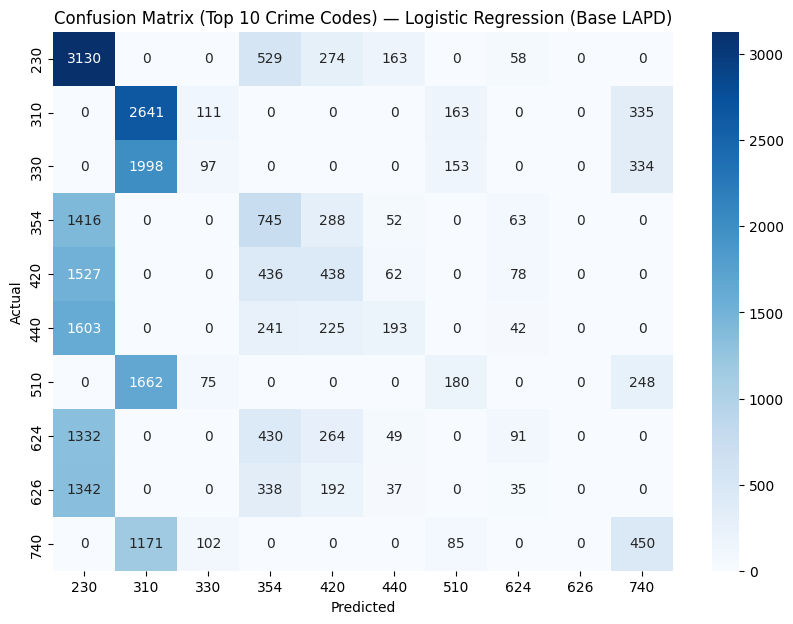

In [13]:
# Logistic Regression predictions
log_y_pred = log_pipe.predict(X_test)

# Add confusion matrix for top 10 classes
plot_top10_confusion_matrix(
    "Logistic Regression (Base LAPD)",
    y_test,
    log_y_pred
)


Model 2: Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pipe, rf_metrics = train_and_evaluate(
    "Random Forest (Base LAPD)",
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_metrics